In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import os

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 64
CLASS_MODE = "binary"

In [ ]:
train_data_gen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.1,
    horizontal_flip=True,
    rotation_range=10,
    brightness_range=[0.8, 1.2]
)

test_data_gen = ImageDataGenerator(
    rescale=1/255.0
)


train_gen = train_data_gen.flow_from_directory(
    os.path.join(path, "chest_xray", "train"),
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = CLASS_MODE,
    subset = "training",
    shuffle = True
)

val_gen = train_data_gen.flow_from_directory(
    os.path.join(path, "chest_xray", "train"),
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = CLASS_MODE,
    subset = "validation",
    shuffle=False
)

test_gen = test_data_gen.flow_from_directory(
    os.path.join(path, "chest_xray", "test"),
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = CLASS_MODE,
    shuffle=False
)


Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


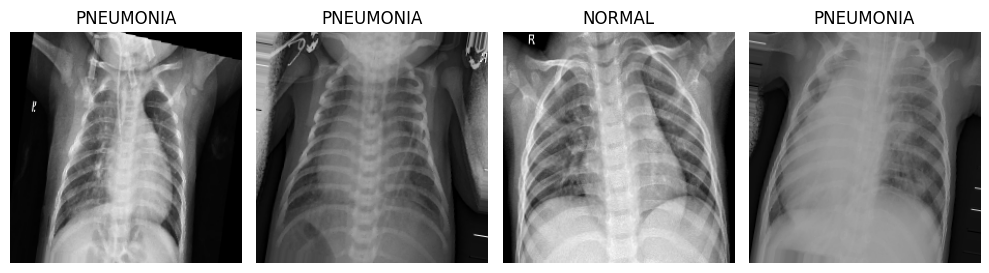

In [ ]:
class_names = list(train_gen.class_indices.keys())
images,labels = next(train_gen)
plt.figure(figsize=(10,4))
for i in range(4):
  ax = plt.subplot(1,4,i+1)
  ax.imshow(images[i])
  ax.set_title(class_names[int(labels[i])])
  ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
base_model = DenseNet121(
    weights = "imagenet",
    include_top = False,
    input_shape = (*IMG_SIZE,3)
)

base_model.trainable= False

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation="relu")(x)
x=Dropout(0.5)(x)
pred =Dense(1,activation="sigmoid")(x)

model=Model(inputs=base_model.inputs,outputs=pred)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks= [
    EarlyStopping(monitor="val_loss",patience=3,verbose=1),
    ModelCheckpoint("model.h5",monitor="val_loss",save_best_only=True,verbose=1),
    ReduceLROnPlateau(monitor="val_loss",factor=0.2 ,patience=2,verbose=1)
]

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
history = model.fit(
     train_gen,
     validation_data = val_gen,
     epochs = 30,
     callbacks = callbacks,
     verbose = 1
)

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8521 - loss: 0.3091
Epoch 1: val_loss improved from None to 0.14511, saving model to model.h5



Epoch 1: finished saving model to model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.8965 - loss: 0.2354 - val_accuracy: 0.9578 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9443 - loss: 0.1487
Epoch 2: val_loss improved from 0.14511 to 0.11427, saving model to model.h5



Epoch 2: finished saving model to model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9431 - loss: 0.1453 - val_accuracy: 0.9635 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9527 - loss: 0.1327
Epoch 3: val_loss did not improve from 0.11427
74/74 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9534 - loss: 0.1306 - val_accuracy: 0.9482 - val_loss: 0.1211 - learning_rate: 0.0010
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9490 - loss: 0.1349
Epoch 4: val_loss did not improve from 0.11427

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
74/74 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9497 - loss: 0.1364 - val_accuracy: 0.9578 - val_loss: 0.1155 - learning_rate: 0.0010
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9570 - loss: 0.1083
Epoch 5: val_loss improved from 0.11427 to 0.09868, saving model to model.h5



Epoch 5: finished saving model to model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9614 - loss: 0.1051 - val_accuracy: 0.9501 - val_loss: 0.0987 - learning_rate: 2.0000e-04
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9646 - loss: 0.1018
Epoch 6: val_loss improved from 0.09868 to 0.09789, saving model to model.h5



Epoch 6: finished saving model to model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9646 - loss: 0.0989 - val_accuracy: 0.9616 - val_loss: 0.0979 - learning_rate: 2.0000e-04
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9648 - loss: 0.0995
Epoch 7: val_loss did not improve from 0.09789
74/74 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9666 - loss: 0.0959 - val_accuracy: 0.9578 - val_loss: 0.1051 - learning_rate: 2.0000e-04
Epoch 8/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9636 - loss: 0.0996
Epoch 8: val_loss improved from 0.09789 to 0.09467, saving model to model.h5



Epoch 8: finished saving model to model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9655 - loss: 0.1015 - val_accuracy: 0.9616 - val_loss: 0.0947 - learning_rate: 2.0000e-04
Epoch 9/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9669 - loss: 0.0946
Epoch 9: val_loss did not improve from 0.09467
74/74 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9653 - loss: 0.0960 - val_accuracy: 0.9616 - val_loss: 0.1021 - learning_rate: 2.0000e-04
Epoch 10/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9697 - loss: 0.0889
Epoch 10: val_loss improved from 0.09467 to 0.08811, saving model to model.h5



Epoch 10: finished saving model to model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9666 - loss: 0.0904 - val_accuracy: 0.9635 - val_loss: 0.0881 - learning_rate: 2.0000e-04
Epoch 11/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9662 - loss: 0.0920
Epoch 11: val_loss did not improve from 0.08811
74/74 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9683 - loss: 0.0929 - val_accuracy: 0.9539 - val_loss: 0.0893 - learning_rate: 2.0000e-04
Epoch 12/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9641 - loss: 0.0963
Epoch 12: val_loss did not improve from 0.08811

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
74/74 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9668 - loss: 0.0890 - val_accuracy: 0.9616 - val_loss: 0.0922 - learning_rate: 2.0000e-04
Epoch 13/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9665 - loss: 0.0839
Epoch 13: val_loss did not improve from 0.08811
74/74 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accura

In [ ]:
pred_probs =  model.predict(test_gen,verbose=1)
pred_labels = (pred_probs>0.5).astype(int).ravel()
true_labels =  test_gen.classes

10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step


<Figure size 1000x1000 with 0 Axes>

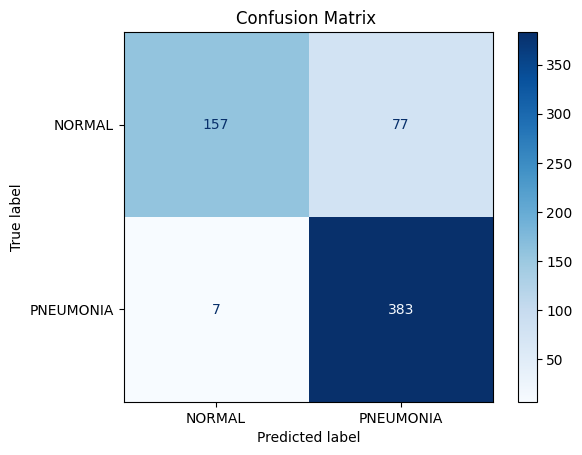

In [ ]:
cm=confusion_matrix(true_labels,pred_labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix ")
plt.show()